In [85]:
import pandas as pd
import numpy as np

# this is used to load raw dataset
data = pd.read_csv('/workspaces/ML_01_video_game_prediction/video_game_analysis/src/data/Video_Games_Sales_as_at_22_Dec_2016.csv')

# this is used to Preview first few rows
data.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


cleaning dataset

In [86]:
data.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')

In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [88]:
#these are the columns I am going to drop.
columns_to_drop = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales']

In [89]:
#to drop the columns.
data = data.drop(columns=columns_to_drop, axis=1)

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   Global_Sales     16719 non-null  float64
 6   Critic_Score     8137 non-null   float64
 7   Critic_Count     8137 non-null   float64
 8   User_Score       10015 non-null  object 
 9   User_Count       7590 non-null   float64
 10  Developer        10096 non-null  object 
 11  Rating           9950 non-null   object 
dtypes: float64(5), object(7)
memory usage: 1.5+ MB


In [91]:
data.isnull()

,Name,Platform,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,True,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
16714,False,False,False,False,False,False,True,True,True,True,True,True
16715,False,False,False,False,False,False,True,True,True,True,True,True
16716,False,False,False,False,False,False,True,True,True,True,True,True
16717,False,False,False,False,False,False,True,True,True,True,True,True


In [92]:
data.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

In [93]:
data = data.dropna(subset=['Name', 'Genre'])

# reset the index
data = data.reset_index(drop=True)

In [94]:
data.isnull().sum()

Name                  0
Platform              0
Year_of_Release     269
Genre                 0
Publisher            54
Global_Sales          0
Critic_Score       8580
Critic_Count       8580
User_Score         6702
User_Count         9127
Developer          6621
Rating             6767
dtype: int64

In [95]:
data['Year_of_Release'] = data['Year_of_Release'].fillna(data['Year_of_Release'].mean())

In [96]:
data['Critic_Score'] = data['Critic_Score'].fillna(data['Critic_Score'].mean())

In [97]:
data['Critic_Count'] = data['Critic_Count'].fillna(data['Critic_Count'].mean())

In [98]:
data["User_Count"] = data["User_Count"].fillna(data["User_Count"].median())

In [99]:
data.isnull().sum()

Name                  0
Platform              0
Year_of_Release       0
Genre                 0
Publisher            54
Global_Sales          0
Critic_Score          0
Critic_Count          0
User_Score         6702
User_Count            0
Developer          6621
Rating             6767
dtype: int64

In [100]:
data["Publisher"] = data["Publisher"].fillna("Unknown")

In [101]:
data["Developer"] = data["Developer"].fillna("Developer")

In [102]:
data["Rating"] = data["Rating"].fillna("Rating")

In [103]:
data.isnull().sum()

Name                  0
Platform              0
Year_of_Release       0
Genre                 0
Publisher             0
Global_Sales          0
Critic_Score          0
Critic_Count          0
User_Score         6702
User_Count            0
Developer             0
Rating                0
dtype: int64

In [104]:
data["User_Score"] = pd.to_numeric(data["User_Score"], errors="coerce")

In [105]:
data["User_Score"] = data["User_Score"].fillna(data["User_Score"].median())

In [106]:
data.isnull().sum()

Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

In [107]:
data.isnull().sum()

Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

In [108]:
data.duplicated().any()

np.False_

In [109]:
print(data.dtypes)

Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score         float64
User_Count         float64
Developer           object
Rating              object
dtype: object


In [110]:
data = data.drop(columns=["Name"])

In [111]:
data

,Platform,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii,2006.0,Sports,Nintendo,82.53,76.000000,51.000000,8.0,322.0,Nintendo,E
1,NES,1985.0,Platform,Nintendo,40.24,68.967679,26.360821,7.5,24.0,Developer,Rating
2,Wii,2008.0,Racing,Nintendo,35.52,82.000000,73.000000,8.3,709.0,Nintendo,E
3,Wii,2009.0,Sports,Nintendo,32.77,80.000000,73.000000,8.0,192.0,Nintendo,E
4,GB,1996.0,Role-Playing,Nintendo,31.37,68.967679,26.360821,7.5,24.0,Developer,Rating
...,...,...,...,...,...,...,...,...,...,...,...
16712,PS3,2016.0,Action,Tecmo Koei,0.01,68.967679,26.360821,7.5,24.0,Developer,Rating
16713,X360,2006.0,Sports,Codemasters,0.01,68.967679,26.360821,7.5,24.0,Developer,Rating
16714,PSV,2016.0,Adventure,Idea Factory,0.01,68.967679,26.360821,7.5,24.0,Developer,Rating
16715,GBA,2003.0,Platform,Wanadoo,0.01,68.967679,26.360821,7.5,24.0,Developer,Rating


In [112]:
data.isnull().sum()

Platform           0
Year_of_Release    0
Genre              0
Publisher          0
Global_Sales       0
Critic_Score       0
Critic_Count       0
User_Score         0
User_Count         0
Developer          0
Rating             0
dtype: int64

data preprocessing

In [113]:
#this code seperate feature and target
X = data.drop("Global_Sales", axis=1)
y = data["Global_Sales"]

In [114]:
#convert categorical columns into numbers to work with Random Forest.
#Label Encoding gives each category a unique number.
# I use LabelEncoding, because it is fine and faster 
# and keeps our feature space lean. But if I use One-Hot Encoding, it can overkill tree-based models.
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["Platform", "Genre", "Publisher", "Developer", "Rating"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]


for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])


In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model training

In [116]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)


In [117]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [118]:
# This used to Predict global sales using test set.
predict_sales = model.predict(X_test)

In [119]:
print(predict_sales[:10])

[0.9747     0.4493     0.20833667 0.976      0.27360667 0.22874333
 0.13906667 0.12814833 0.3186     0.4373    ]


In [120]:
for actual, predicted in zip(y_test[:10], predict_sales[:10]):
    print(f"Actual: {actual:.2f}, Predicted: {predicted:.2f}")

Actual: 0.45, Predicted: 0.97
Actual: 0.04, Predicted: 0.45
Actual: 0.11, Predicted: 0.21
Actual: 0.52, Predicted: 0.98
Actual: 0.28, Predicted: 0.27
Actual: 0.06, Predicted: 0.23
Actual: 0.49, Predicted: 0.14
Actual: 0.10, Predicted: 0.13
Actual: 0.25, Predicted: 0.32
Actual: 0.66, Predicted: 0.44


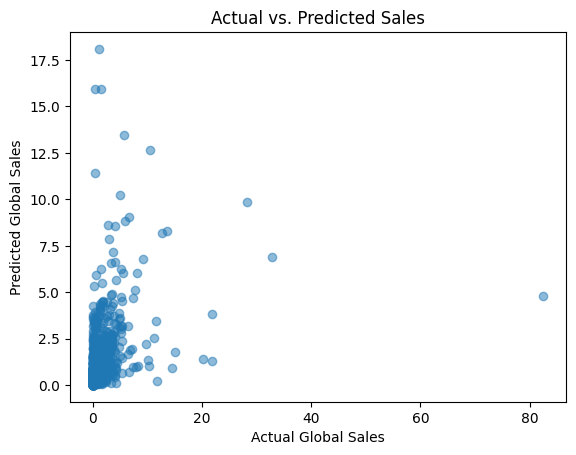

In [121]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predict_sales, alpha=0.5)
plt.xlabel("Actual Global Sales")
plt.ylabel("Predicted Global Sales")
plt.title("Actual vs. Predicted Sales")
plt.show()

model evaluation

In [122]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [123]:
mae = mean_absolute_error(y_test, predict_sales)

In [124]:
print(f"MAE: {mae:.3f}")

MAE: 0.458


In [125]:
rmse = np.sqrt(mean_squared_error(y_test, predict_sales))

In [126]:
print(f"RMSE: {rmse:.3f}")

RMSE: 1.871


In [127]:
r2 = r2_score(y_test, predict_sales)

In [128]:
print(f"R2: {r2:.3f}")

R2: 0.152
